## Data from World Happiness Report

The World Happiness Report is an annual publication of the United Nations Sustainable Development Solutions Network. It contains articles, and rankings of national happiness based on respondent ratings of their own lives, which the report also correlates with various life factors.

In this notebook we will explore the happiness of different countries and the features associated.
The datasets that we will use are available in *Data*: **happiness2020.pkl** and **countries_info.csv**.

Although the features are self-explanatory, here a summary: 

**happiness2020.pkl**
* country: *Name of the country*
* happiness_score: *Happiness score*
* social_support: *Social support (mitigation the effects of inequality)*
* healthy_life_expectancy: *Healthy Life Expectancy*
* freedom_of_choices: *Freedom to make life choices*
* generosity: *Generosity (charity, volunteers)*
* perception_of_corruption: *Corruption Perception*
* world_region: *Area of the world of the country*

**countries_info.csv**
* country_name: *Name of the country*
* area: *Area in sq mi*
* population: *Number of people*
* literacy: *Literacy percentage*

In [120]:
!head Data/countries_info.csv

'head' is not recognized as an internal or external command,
operable program or batch file.


In [121]:
import pandas as pd
%matplotlib inline

DATA_FOLDER = 'Data/'

HAPPINESS_DATASET = DATA_FOLDER+"happiness2020.csv"
COUNTRIES_DATASET = DATA_FOLDER+"countries_info.csv"

## Task 1: Load the data

Load the 2 datasets in Pandas dataframes (called *happiness* and *countries*), and show the first rows.


**Hint**: Use the correct reader and verify the data has the expected format.

In [122]:
#countries_info = pd.read_csv(COUNTRIES_DATASET, sep=',')
countries_info = pd.read_csv(COUNTRIES_DATASET, decimal=',')
countries_info.head()

,country_name,area,population,literacy
0,afghanistan,647500,31056997,36.0
1,albania,28748,3581655,86.5
2,algeria,2381740,32930091,70.0
3,argentina,2766890,39921833,97.1
4,armenia,29800,2976372,98.6


In [123]:
#happiness = pd.read_csv(HAPPINESS_DATASET)
happiness = pd.read_pickle("Data/happiness2020.pkl")
happiness.head()

,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region
0,Afghanistan,2.5669,0.470367,52.590000,0.396573,-0.096429,0.933687,South Asia
1,Albania,4.8827,0.671070,68.708138,0.781994,-0.042309,0.896304,Central and Eastern Europe
2,Algeria,5.0051,0.803385,65.905174,0.466611,-0.121105,0.735485,Middle East and North Africa
3,Argentina,5.9747,0.900568,68.803802,0.831132,-0.194914,0.842010,Latin America and Caribbean
4,Armenia,4.6768,0.757479,66.750656,0.712018,-0.138780,0.773545,Commonwealth of Independent States


## Task 2: Let's merge the data

Create a dataframe called *country_features* by merging *happiness* and *countries*. A row of this dataframe must describe all the features that we have about a country.

**Hint**: Verify that all the rows are in the final dataframe.

In [124]:
happiness['country_name'] = happiness['country'].str.lower()

country_features = happiness.merge(countries_info, on="country_name")
country_features.drop("country_name", axis=1, inplace=True)
country_features.head()

,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,area,population,literacy
0,Afghanistan,2.5669,0.470367,52.590000,0.396573,-0.096429,0.933687,South Asia,647500,31056997,36.0
1,Albania,4.8827,0.671070,68.708138,0.781994,-0.042309,0.896304,Central and Eastern Europe,28748,3581655,86.5
2,Algeria,5.0051,0.803385,65.905174,0.466611,-0.121105,0.735485,Middle East and North Africa,2381740,32930091,70.0
3,Argentina,5.9747,0.900568,68.803802,0.831132,-0.194914,0.842010,Latin America and Caribbean,2766890,39921833,97.1
4,Armenia,4.6768,0.757479,66.750656,0.712018,-0.138780,0.773545,Commonwealth of Independent States,29800,2976372,98.6


## Task 3: Where are people happier?

Print the top 10 countries based on their happiness score (higher is better).

In [125]:
country_features.sort_values(by="happiness_score",ascending=False, inplace=True)
country_features[["country", "happiness_score"]].head(10)

,country,happiness_score
38,Finland,7.8087
31,Denmark,7.6456
115,Switzerland,7.5599
50,Iceland,7.5045
92,Norway,7.4880
87,Netherlands,7.4489
114,Sweden,7.3535
88,New Zealand,7.2996
6,Austria,7.2942
72,Luxembourg,7.2375


We are interested to know in what world region people are happier. 

Create and print a dataframe with the (1) average happiness score and (2) the number of contries for each world region.
Sort the result to show the happiness ranking.

In [126]:
country_features.columns


Index(['country', 'happiness_score', 'social_support',
       'healthy_life_expectancy', 'freedom_of_choices', 'generosity',
       'perception_of_corruption', 'world_region', 'area', 'population',
       'literacy'],
      dtype='str')

In [127]:
country_features.groupby("world_region")["happiness_score"].mean()


world_region
Central and Eastern Europe            5.891393
Commonwealth of Independent States    5.358342
East Asia                             5.483633
Latin America and Caribbean           5.971280
Middle East and North Africa          5.269306
North America and ANZ                 7.173525
South Asia                            4.355083
Southeast Asia                        5.517788
Sub-Saharan Africa                    4.393856
Western Europe                        6.967405
Name: happiness_score, dtype: float64

In [128]:

country_features.groupby("world_region")["country"].count()


world_region
Central and Eastern Europe            14
Commonwealth of Independent States    12
East Asia                              3
Latin America and Caribbean           20
Middle East and North Africa          16
North America and ANZ                  4
South Asia                             6
Southeast Asia                         8
Sub-Saharan Africa                    32
Western Europe                        20
Name: country, dtype: int64

In [129]:
country_features.groupby("world_region").agg({
    "country": "count",
    "happiness_score": "mean"
}).sort_values(["happiness_score"], ascending=False)

,country,happiness_score
world_region,,
North America and ANZ,4,7.173525
Western Europe,20,6.967405
Latin America and Caribbean,20,5.971280
Central and Eastern Europe,14,5.891393
Southeast Asia,8,5.517788
East Asia,3,5.483633
Commonwealth of Independent States,12,5.358342
Middle East and North Africa,16,5.269306
Sub-Saharan Africa,32,4.393856


The first region has only a few countries! What are them and what is their score?

In [130]:
country_features[country_features["world_region"] == "North America and ANZ"].sort_values(["happiness_score"], ascending=False)[["country","happiness_score"]]

,country,happiness_score
88,New Zealand,7.2996
21,Canada,7.2321
5,Australia,7.2228
127,United States,6.9396


## Task 4: How literate is the world?

Print the names of the countries with a level of literacy of 100%. 

For each country, print the name and the world region in the format: *{region name} - {country name} ({happiness score})*

In [131]:
country_features[country_features["literacy"] == "100,0"].head()

,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,area,population,literacy


In [149]:
for idx, row in country_features[country_features["literacy"] == 100].iterrows():
    print("{} - {} ({})".format(row.world_region, row.country, row.happiness_score))


Western Europe - Finland (7.808700085)
Western Europe - Denmark (7.645599842)
Western Europe - Norway (7.487999916000001)
Western Europe - Luxembourg (7.2375001910000005)
North America and ANZ - Australia (7.222799778)


What is the global average?

In [133]:
country_features["literacy"].head()

38     100.0
31     100.0
115     99.0
50      99.9
92     100.0
Name: literacy, dtype: float64

In [134]:
country_features.literacy.mean()

np.float64(81.85112781954888)

Calculate the proportion of countries with a literacy level below 50%. Print the value in percentage, formatted with 2 decimals.

In [146]:
len(country_features[country_features["literacy"] < 50]) / len(country_features) * 100

11.851851851851853

Print the raw number and the percentage of world population that is illiterate.

In [153]:
illiterate_people = country_features.population * (100-country_features.literacy)/100
print("Illiterate people : ", illiterate_people.sum())

print("Percentage : ", illiterate_people.sum()/country_features.population.sum()*100)

Illiterate people :  1249372988.1029997
Percentage :  20.329965829650828


## Task 5: Population density

Add to the dataframe a new field called *population_density* computed by dividing *population* by *area*.

In [154]:
country_features["population_density"] = country_features.population/country_features.area

country_features.head()

,country,happiness_score,social_support,healthy_life_expectancy,freedom_of_choices,generosity,perception_of_corruption,world_region,area,population,literacy,population_density
38,Finland,7.8087,0.954330,71.900825,0.949172,-0.059482,0.195445,Western Europe,338145,5231372,100.0,15.470795
31,Denmark,7.6456,0.955991,72.402504,0.951444,0.066202,0.168489,Western Europe,43094,5450661,100.0,126.483060
115,Switzerland,7.5599,0.942847,74.102448,0.921337,0.105911,0.303728,Western Europe,41290,7523934,99.0,182.221700
50,Iceland,7.5045,0.974670,73.000000,0.948892,0.246944,0.711710,Western Europe,103000,299388,99.9,2.906680
92,Norway,7.4880,0.952487,73.200783,0.955750,0.134533,0.263218,Western Europe,323802,4610820,100.0,14.239628


What is the happiness score of the 3 countries with the lowest population density?

In [159]:
country_features.sort_values(["population_density"]).head(3)[["country","happiness_score","population_density"]]

,country,happiness_score,population_density
83,Mongolia,5.4562,1.810751
5,Australia,7.2228,2.636201
14,Botswana,3.4789,2.731371


## Task 6: Healty and happy?

Plot in a scatter plot the happiness score (x) and healty life expectancy (y).

<Axes: xlabel='happiness_score', ylabel='healthy_life_expectancy'>

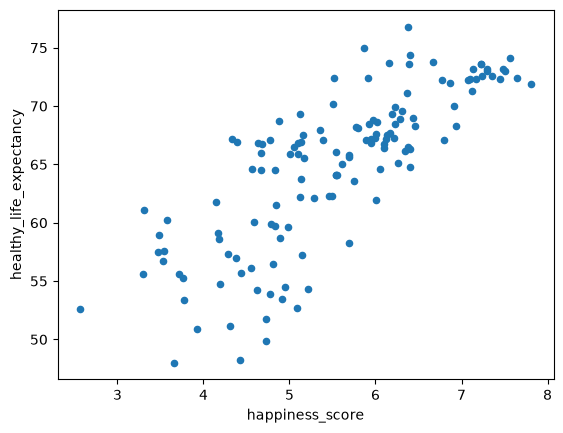

In [163]:
country_features.plot(x="happiness_score", y="healthy_life_expectancy", kind="scatter")

Feel free to continue the exploration of the dataset! We'll release the solutions next week.

----
Enjoy EPFL and be happy, next year Switzerland must be #1.